In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from scellst.constant import METRICS_DIR
from scellst.utils import split_to_dict
from scellst.metrics.metric_utils import format_metric_df

from sCellST_reproducibility.reproducibility_figures.utils_plot import plot_metrics_simulation
from sCellST_reproducibility.reproducibility_figures.utils_analyses import select_best_lr_model

%load_ext autoreload
%autoreload 2

17:13:15 INFO: PROJ_ROOT path is: /home/loic/PycharmProjects/CellST


In [2]:
# Params plot
plt.rcParams.update({"font.size": 14})
pd.options.display.float_format = '{:,.4f}'.format

In [3]:
SAVE_DIR_TAG = "simulation"

LIST_MODEL_TYPE = ["mil", "supervised"]

SAVE_PATH = Path("figures/simulations")
SAVE_PATH.mkdir(exist_ok=True, parents=True)

In [4]:
# Prepare paths
all_metrics_paths = []
for model_type in LIST_MODEL_TYPE:
    # Prepare paths
    metrics_dir = METRICS_DIR / SAVE_DIR_TAG / model_type
    metrics_paths = list(metrics_dir.iterdir())
    print(f"Found {len(metrics_paths)} paths for model: {model_type}")
    all_metrics_paths.extend(metrics_paths)

Found 144 paths for model: mil
Found 152 paths for model: supervised


In [5]:
# Load metrics
all_df = []
for path in tqdm(all_metrics_paths):
    df = pd.read_csv(path, index_col=0)
    df = df.fillna(0.)  # Fill NaN values with 0. (failed runs)
    all_df.append(df)

# Concatenate all metrics
metrics = pd.concat(all_df).reset_index(drop=True)
metrics["tag"] = [path.stem for path in all_metrics_paths]

  0%|          | 0/296 [00:00<?, ?it/s]

In [6]:
# Format metrics for plotting
metrics = format_metric_df(metrics)
df_hp = pd.DataFrame(metrics["tag"].apply(split_to_dict).to_list())
metrics = pd.concat([metrics, df_hp], axis=1)

list_hp = df_hp.columns.sort_values(ascending=True).tolist()
list_hp.remove("train_slide")
print(f"Found {list_hp} parameters.")

Found ['dataset_handler', 'embedding_tag', 'genes', 'infer_mode', 'lr', 'scale', 'task_type', 'test_slide'] parameters.


In [7]:
dict_rename = {
    "embedding_tag": {
        "moco-TENX65-rn50": "SSL embedding",
        "one-hot-celltype": "one hot encoded cell type"
    },
    "test_slide": {
        "TENX65_sim_cell_test": "cell",
        "TENX65_sim_centroid_test": "centroid",
        "TENX65_sim_random_test": "random",
    },
    "genes": {
        "1000_hvg_sim": "HVG",
        "marker_sim": "MG",
    },
    "task_type": {
        "nb_mean_regression": "NB (mean parametrisation)",
        "nb_total_regression": "NB (total counts parametrisation)",
    },
    "dataset_handler": {"mil": "MIL", "supervised": "Supervised"},
}
metrics = metrics.replace(dict_rename)
col_rename = {
    "dataset_handler": "learning framework",
    "test_slide": "scenario"
}
metrics = metrics.rename(columns=col_rename)
metrics = metrics.rename(columns=lambda name: name.replace('_', ' '))

In [8]:
metrics["lr"] = metrics["lr"].astype(float)
metrics["category"] = metrics["infer mode"] + " " + metrics["genes"]

# 1. Plots

Plot: Comparison of different scenarios on HVG
infer mode  scenario
bag         cell        1000
            centroid    1000
            random      1000
instance    cell        1000
            centroid    1000
            random      1000
dtype: int64
infer mode  scenario
bag         cell        0.2039
            centroid    0.9343
            random     -0.0017
instance    cell        0.2279
            centroid    0.9276
            random      0.0012
Name: pcc, dtype: float64


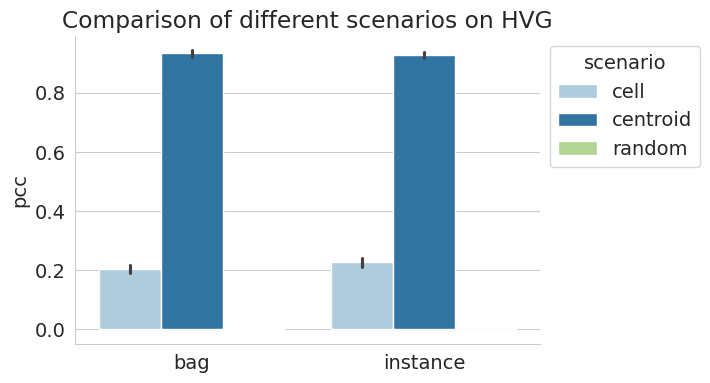

Plot: Comparison of different scenarios on HVG
infer mode  scenario
bag         cell        1000
            centroid    1000
            random      1000
instance    cell        1000
            centroid    1000
            random      1000
dtype: int64
infer mode  scenario
bag         cell        0.2122
            centroid    0.9495
            random     -0.0016
instance    cell        0.1763
            centroid    0.6896
            random      0.0014
Name: scc, dtype: float64


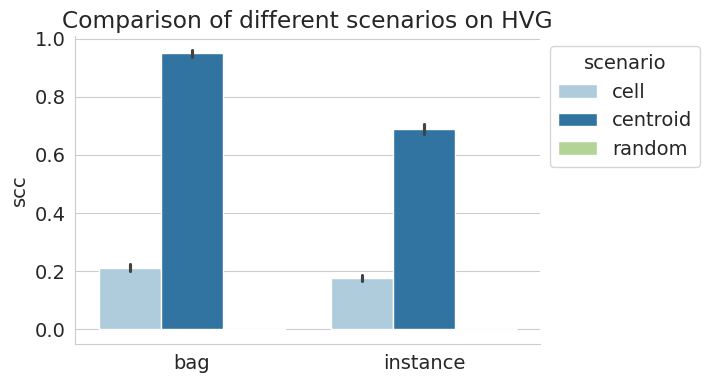

In [9]:
df_plot = metrics[
    (metrics["task type"] == "regression")
    & (metrics["embedding tag"] == "SSL embedding")
    & (metrics["genes"] == "HVG")
    & (metrics["lr"] == 0.0001)
    & (metrics["learning framework"] == "MIL")
].copy()
for score in ["pcc", "scc"]:
    plot_metrics_simulation(
        df_plot,
        x="infer mode",
        y=score,
        save_path= SAVE_PATH / f"comparison_scenario_test_regression_{score}.png",
        title="Comparison of different scenarios on HVG",
        hue="scenario",
        # x_order=["spot level", "cell level"],
        # hue_order=["random", "centroid", "cell"],
    )

Plot: Comparison of different gene sets
 in cell scenario
infer mode  genes
bag         HVG      1000
            MG       1000
instance    HVG      1000
            MG       1000
dtype: int64
infer mode  genes
bag         HVG     0.2039
            MG      0.6811
instance    HVG     0.2279
            MG      0.7640
Name: pcc, dtype: float64


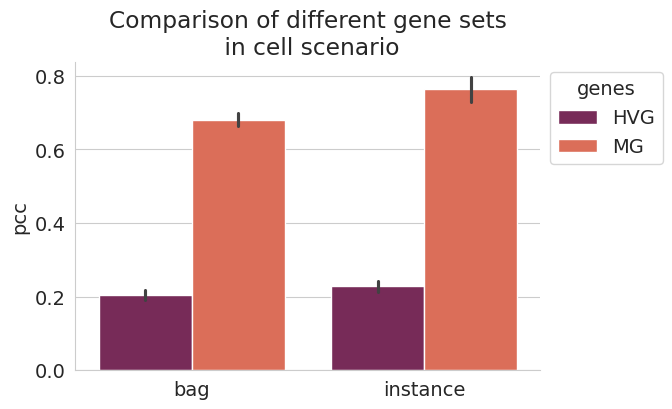

Plot: Comparison of different gene sets
 in cell scenario
infer mode  genes
bag         HVG      1000
            MG       1000
instance    HVG      1000
            MG       1000
dtype: int64
infer mode  genes
bag         HVG     0.2122
            MG      0.7528
instance    HVG     0.1763
            MG      0.5687
Name: scc, dtype: float64


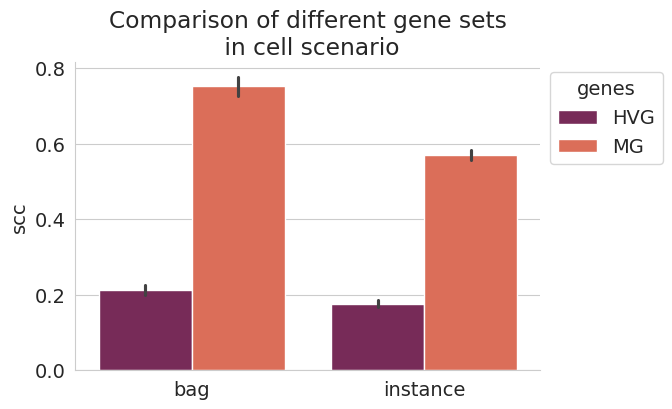

In [15]:
df_plot = metrics[
    (metrics["task type"] == "regression")
    & (metrics["embedding tag"] == "SSL embedding")
    & (metrics["lr"] == 0.0001)
    & (metrics["learning framework"] == "MIL")
    & (metrics["scenario"] == "cell")
].copy()
for score in ["pcc", "scc"]:
    plot_metrics_simulation(
        df_plot,
        x="infer mode",
        y=score,
        hue="genes",
        save_path=SAVE_PATH / f"comparison_scenario_test_regression_{score}_genes.png",
        title="Comparison of different gene sets\n in cell scenario",
        # x_order=["spot level", "cell level"],
        # hue_order=["hvg", "marker"],
    )

                            task type     lr    pcc
0           NB (mean parametrisation) 0.0000 0.6872
1           NB (mean parametrisation) 0.0001 0.7328
2           NB (mean parametrisation) 0.0010 0.6956
3           NB (mean parametrisation) 0.0100 0.7535
4   NB (total counts parametrisation) 0.0000 0.1271
5   NB (total counts parametrisation) 0.0001 0.6831
6   NB (total counts parametrisation) 0.0010 0.7589
7   NB (total counts parametrisation) 0.0100 0.7344
8                          regression 0.0000 0.7063
9                          regression 0.0001 0.7176
10                         regression 0.0010 0.7090
11                         regression 0.0100 0.7176
Plot: Comparison of different losses
 in the cell scenario on MG
infer mode  task type                        
bag         NB (mean parametrisation)            1000
            NB (total counts parametrisation)    1000
            regression                           1000
instance    NB (mean parametrisation)            10

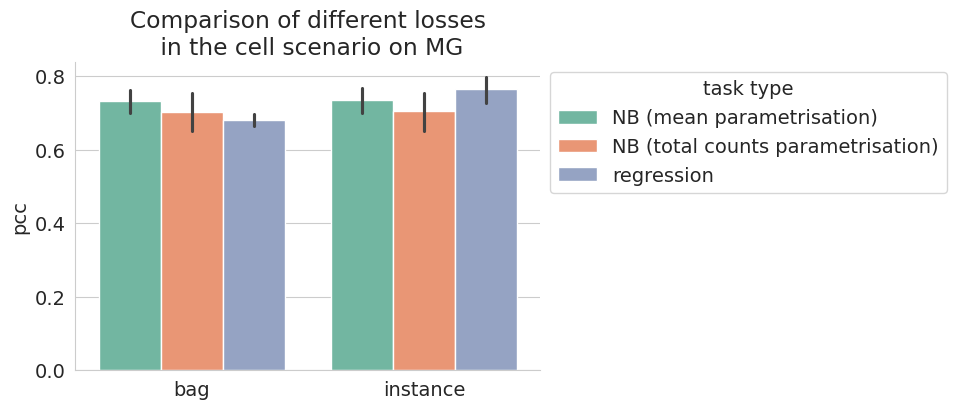

                            task type     lr    scc
0           NB (mean parametrisation) 0.0000 0.5742
1           NB (mean parametrisation) 0.0001 0.5842
2           NB (mean parametrisation) 0.0010 0.5785
3           NB (mean parametrisation) 0.0100 0.6179
4   NB (total counts parametrisation) 0.0000 0.1284
5   NB (total counts parametrisation) 0.0001 0.5612
6   NB (total counts parametrisation) 0.0010 0.5982
7   NB (total counts parametrisation) 0.0100 0.6004
8                          regression 0.0000 0.6195
9                          regression 0.0001 0.6282
10                         regression 0.0010 0.6213
11                         regression 0.0100 0.6268
Plot: Comparison of different losses
 in the cell scenario on MG
infer mode  task type                        
bag         NB (mean parametrisation)            1000
            NB (total counts parametrisation)    1000
            regression                           1000
instance    NB (mean parametrisation)            10

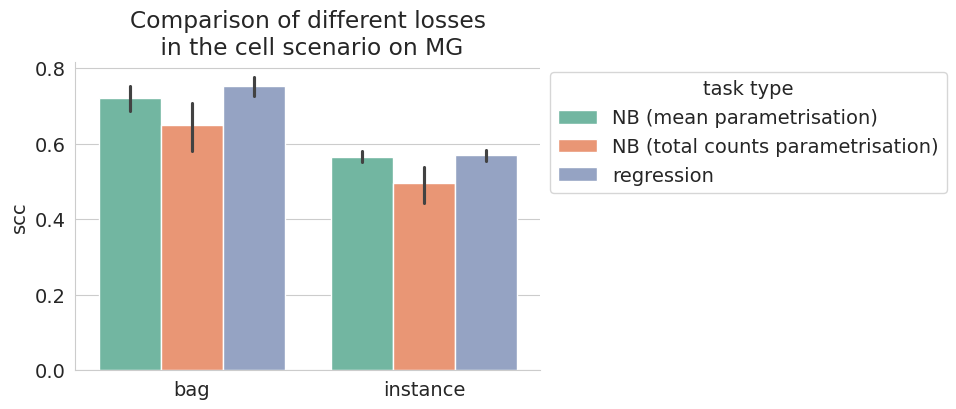

In [11]:
df_plot = metrics[
    (metrics["embedding tag"] == "SSL embedding")
    & (metrics["scenario"] == "cell")
    & (metrics["genes"] == "MG")
    & (metrics["learning framework"] == "MIL")
].copy()
for score in ["pcc", "scc"]:
    df_plot_ = select_best_lr_model(
        df_plot, columns=["task type", "lr"], metric=score, gene_cat="MG"
    )
    plot_metrics_simulation(
        df_plot_,
        x="infer mode",
        y=score,
        save_path=SAVE_PATH / f"comparison_losses_test_cell_{score}.png",
        title="Comparison of different losses\n in the cell scenario on MG",
        hue="task type",
        # x_order=["spot level", "cell level"],
        # hue_order=["regression", "NB (mean parametrisation)", "NB (total count parametrisation)"],
    )

               embedding tag     lr    pcc
0              SSL embedding 0.0000 0.7700
1              SSL embedding 0.0001 0.7941
2              SSL embedding 0.0010 0.7827
3              SSL embedding 0.0100 0.7935
4  one hot encoded cell type 0.0000 0.7664
5  one hot encoded cell type 0.0001 0.8101
6  one hot encoded cell type 0.0010 0.8098
7  one hot encoded cell type 0.0100 0.8091
Plot: Comparison of different input types
in cell scenario at the instance level
genes  embedding tag            
HVG    SSL embedding                4000
       one hot encoded cell type    4000
MG     SSL embedding                4000
       one hot encoded cell type    4000
dtype: int64
genes  embedding tag            
HVG    SSL embedding               0.1977
       one hot encoded cell type   0.2325
MG     SSL embedding               0.7542
       one hot encoded cell type   0.7639
Name: pcc, dtype: float64


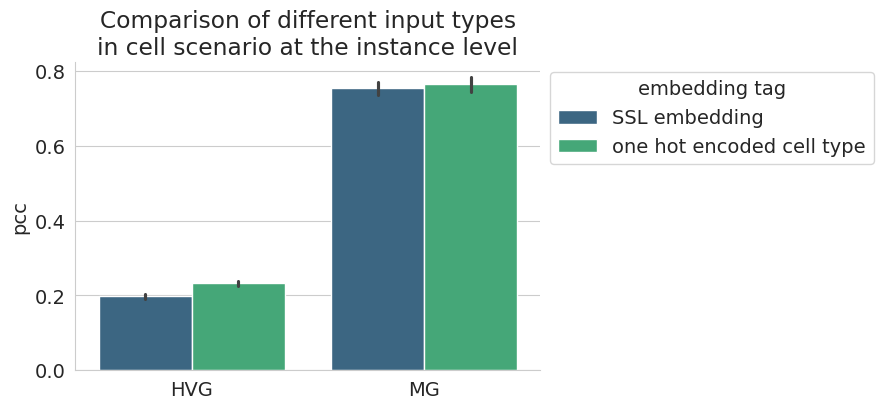

               embedding tag     lr    scc
0              SSL embedding 0.0000 0.5689
1              SSL embedding 0.0001 0.5746
2              SSL embedding 0.0010 0.5711
3              SSL embedding 0.0100 0.5695
4  one hot encoded cell type 0.0000 0.5685
5  one hot encoded cell type 0.0001 0.5856
6  one hot encoded cell type 0.0010 0.5853
7  one hot encoded cell type 0.0100 0.5836
Plot: Comparison of different input types
in cell scenario at the instance level
genes  embedding tag            
HVG    SSL embedding                4000
       one hot encoded cell type    4000
MG     SSL embedding                4000
       one hot encoded cell type    4000
dtype: int64
genes  embedding tag            
HVG    SSL embedding               0.1507
       one hot encoded cell type   0.1758
MG     SSL embedding               0.5659
       one hot encoded cell type   0.5740
Name: scc, dtype: float64


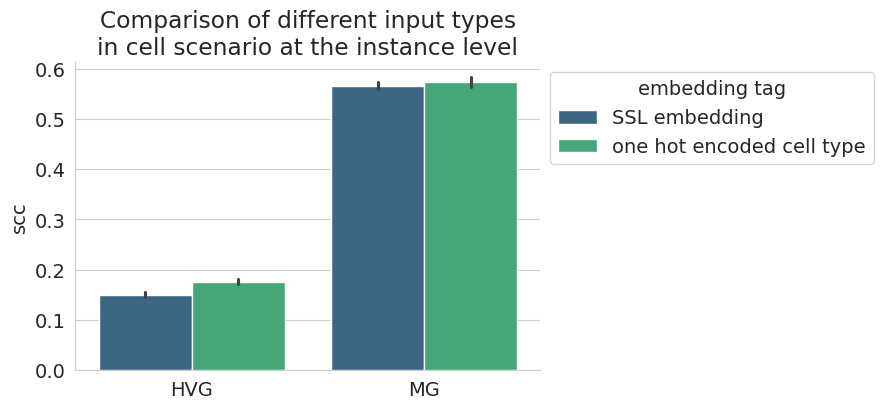

In [12]:
df_plot = metrics[
    (metrics["scenario"] == "cell")
    & (metrics["learning framework"] == "MIL")
    & (metrics["infer mode"] == "instance")
    & (metrics["task type"] == "regression")
].copy()
for score in ["pcc", "scc"]:
    df_plot_ = select_best_lr_model(
        df_plot, columns=["embedding tag", "lr"], metric=score, gene_cat="MG"
    )
    plot_metrics_simulation(
        df_plot,
        x="genes",
        y=score,
        title="Comparison of different input types\nin cell scenario at the instance level",
        save_path= SAVE_PATH / f"comparison_input_type_test_cell_{score}.png",
        hue="embedding tag",
        # x_order=["hvg", "marker"],
    )

In [13]:
df_plot = metrics[
    (metrics["scenario"] == "cell")
    & (metrics["task type"] == "regression")
    & (metrics["embedding tag"] == "SSL embedding")
    & (metrics["infer mode"] == "instance")
    & (metrics["scale"] != "slide_scaling")
].copy()

  learning framework     lr    pcc
0                MIL 0.0000 0.7700
1                MIL 0.0001 0.7941
2                MIL 0.0010 0.7827
3                MIL 0.0100 0.7935
4         Supervised 0.0000 0.7465
5         Supervised 0.0001 0.7426
6         Supervised 0.0010 0.7514
7         Supervised 0.0100 0.8060
Plot: Comparison of different learning frameworks 
in cell scenario at the instance level
genes  learning framework
HVG    MIL                   1000
       Supervised            1000
MG     MIL                   1000
       Supervised            1000
dtype: int64
genes  learning framework
HVG    MIL                  0.2279
       Supervised           0.2030
MG     MIL                  0.7640
       Supervised           0.7820
Name: pcc, dtype: float64


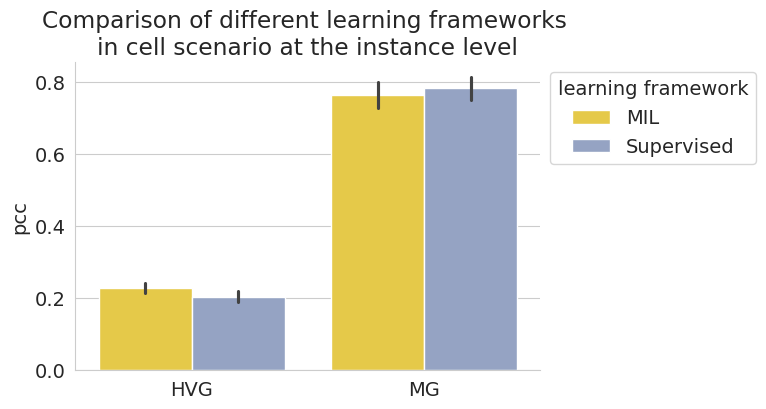

  learning framework     lr    scc
0                MIL 0.0000 0.5689
1                MIL 0.0001 0.5746
2                MIL 0.0010 0.5711
3                MIL 0.0100 0.5695
4         Supervised 0.0000 0.6306
5         Supervised 0.0001 0.7101
6         Supervised 0.0010 0.6793
7         Supervised 0.0100 0.5743
Plot: Comparison of different learning frameworks 
in cell scenario at the instance level
genes  learning framework
HVG    MIL                   1000
       Supervised            1000
MG     MIL                   1000
       Supervised            1000
dtype: int64
genes  learning framework
HVG    MIL                  0.1763
       Supervised           0.1897
MG     MIL                  0.5687
       Supervised           0.6952
Name: scc, dtype: float64


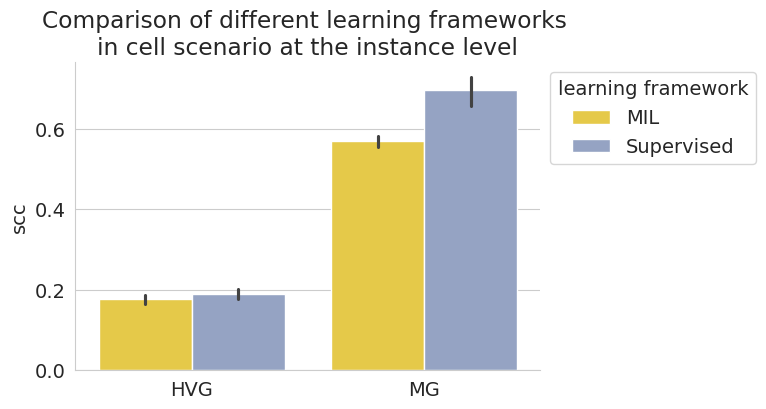

In [14]:
df_plot = metrics[
    (metrics["scenario"] == "cell")
    & (metrics["task type"] == "regression")
    & (metrics["embedding tag"] == "SSL embedding")
    & (metrics["infer mode"] == "instance")
    & (metrics["scale"] != "slide_scaling")
].copy()
for score in ["pcc", "scc"]:
    df_plot_ = select_best_lr_model(
        df_plot, columns=["learning framework", "lr"], metric=score, gene_cat="MG"
    )
    plot_metrics_simulation(
        df_plot_,
        x="genes",
        y=score,
        title="Comparison of different learning frameworks \nin cell scenario at the instance level",
        save_path=SAVE_PATH / f"comparison_learning_framework_test_cell_{score}.png",
        hue="learning framework",
    )